In [2]:
import shutil
import os

checkpoint_folder = "/content/sample_data/train/.ipynb_checkpoints"

if os.path.exists(checkpoint_folder):
    shutil.rmtree(checkpoint_folder)
    print("Deleted .ipynb_checkpoints")
else:
    print("Folder not found")

Folder not found


In [6]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set the paths to the training and validation data
train_data_dir = '/content/dataset'
validation_data_dir = '/content/dataset'

# Set the parameters for the CNN
img_width, img_height = 150, 150
batch_size = 32
epochs = 10
num_classes = 2  # For binary classification, set this to the number of classes (e.g., 2)

# Function to create the CNN model
def create_model():
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'] )
    return model

# Data augmentation for the training set
train_datagen = ImageDataGenerator(rescale=1.0/255,  # Normalize pixel values between 0 and 1
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

# Rescaling the validation set
validation_datagen = ImageDataGenerator(rescale=1.0/255)

# Loading the training data
train_generator = train_datagen.flow_from_directory(train_data_dir,
                                                    target_size=(img_width, img_height),
                                                    batch_size=batch_size,
                                                    class_mode='binary')  # For binary classification, use 'binary' instead

# Loading the validation data
validation_generator = validation_datagen.flow_from_directory(validation_data_dir,
                                                              target_size=(img_width, img_height),
                                                              batch_size=batch_size,
                                                              class_mode='binary')  # For binary classification, use 'binary' instead



Found 10 images belonging to 3 classes.
Found 10 images belonging to 3 classes.


In [7]:
# import os

# print(os.listdir('/content/sample_data/train'))

In [8]:
# Creating the CNN model
model = create_model()

# Train the model
model.fit(train_generator,
          steps_per_epoch=len(train_generator),
          epochs=epochs,
          validation_data=validation_generator,
          validation_steps=len(validation_generator))

# Save the model for future use
model.save('binary_image_classifier.h5')

print("Training and validation completed!")

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - loss: 0.5748 - val_accuracy: 0.5000 - val_loss: -5.9811
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step - accuracy: 0.5000 - loss: -5.8927 - val_accuracy: 0.5000 - val_loss: -18.7053
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 618ms/step - accuracy: 0.5000 - loss: -18.2622 - val_accuracy: 0.5000 - val_loss: -43.6694
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 619ms/step - accuracy: 0.5000 - loss: -42.6239 - val_accuracy: 0.5000 - val_loss: -86.2866
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 629ms/step - accuracy: 0.5000 - loss: -85.3626 - val_accuracy: 0.5000 - val_loss: -154.1320
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step - accuracy: 0.5000 - loss: -151.5469 - val_accuracy: 0.5000 - val_loss: -258.1960
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step - accuracy: 0.5000 - loss: -256.5495 - val_accuracy: 0.5000 - val_loss: -411.7186
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step - accuracy: 0.5000 - loss: -405.6960 - val

Training and validation completed!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


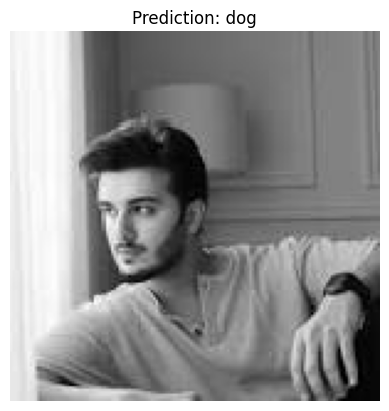

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load the trained model
model = load_model('/content/binary_image_classifier.h5')  # Replace 'binary_image_classifier.h5' with the actual model file name

# Load and preprocess the test image
img_path = '/content/dataset/male/mal1.jpeg'  # Replace this with the actual path to the test image
img = image.load_img(img_path, target_size=(150, 150))  # Assuming the same target size as used during training
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x /= 255.0  # Normalize pixel values between 0 and 1, just like during training

# Perform inference
predictions = model.predict(x)

# Check the prediction result
pred = predictions[0][0]

if pred >= 0.5:
    result = "dog"      # or "cat" depending on class_indices
else:
    result = "cat"

# Display the image and the result
plt.imshow(img)
plt.title(f"Prediction: {result}")
plt.axis('off')
plt.show()

In [14]:
print(predictions)
print(predictions.shape)

[[1.]]
(1, 1)


In [15]:
model.save('/content/binary_image_classifier.keras')
print("Model saved in native keras format: /content/binary_image_classifier.keras")

Model saved in native keras format: /content/binary_image_classifier.keras
